# **Day 17: Missing Values and Outliers**
*Module 3 - Data Preparation and Feature Engineering*

Real datasets have holes (sensor failures, clouds, unanswered questions) and strange values (typos, broken instruments, rare-but-real events). Handling them badly biases models; handling them well can be worth more than a better algorithm.

> Real data has holes (missing values) and strange points (outliers). We must decide whether to drop, fill or keep them, and the choice can change the results. Simple filling with the mean is often worse than it looks.
>
> *Example:* Cloud-covered dates leave gaps in an NDVI time series. Filling them by interpolating between clear dates is better than using the yearly average.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
rng = np.random.default_rng(17)

## **1. Missingness Mechanisms**

| Mechanism | Meaning | Example | Consequence |
|---|---|---|---|
| **MCAR** (completely at random) | Missingness unrelated to anything | Random data-logger failure | Deletion is unbiased (but wastes data) |
| **MAR** (at random) | Depends on **observed** variables | Older patients skip a test; cloudy pixels in monsoon months | Imputation using other features works |
| **MNAR** (not at random) | Depends on the **missing value itself** | High earners hide income; sensor saturates at high values | Hard; needs domain modelling |

Let us simulate each and see what deletion does to the mean.

In [2]:
n = 5000
age = rng.normal(50, 12, n)
income = 20 + 0.8 * age + rng.normal(0, 8, n)                 # true mean of income
true_mean = income.mean()
masks = {"MCAR": rng.random(n) < 0.3,
         "MAR (depends on age)": rng.random(n) < 1 / (1 + np.exp(-(age - 55) / 5)),
         "MNAR (depends on income)": rng.random(n) < 1 / (1 + np.exp(-(income - 65) / 4))}
for name, m in masks.items():
    print(f"{name:<26} missing {m.mean():.0%} | mean of observed = {income[~m].mean():.2f} (true {true_mean:.2f})")

MCAR                       missing 30% | mean of observed = 60.25 (true 60.16)
MAR (depends on age)       missing 38% | mean of observed = 55.41 (true 60.16)
MNAR (depends on income)   missing 37% | mean of observed = 53.57 (true 60.16)


Under MAR and MNAR, simply dropping rows **biases** the result.

## **2. Imputation Methods**
We build a realistic dataset, delete values with a MAR mechanism, and compare imputers by how close they get to the hidden true values.

In [3]:
corr = 0.7 ** np.abs(np.subtract.outer(np.arange(6), np.arange(6)))     # neighbouring features correlated
Xfull = rng.normal(size=(1500, 6)) @ np.linalg.cholesky(corr).T
beta = np.array([3.0, 2.0, 0.0, -1.5, 1.0, 0.5])                           # true coefficients
yfull = Xfull @ beta + rng.normal(0, 1, 1500)
df_true = pd.DataFrame(Xfull, columns=[f"x{i}" for i in range(6)])
df = df_true.copy()
for c in ["x1", "x3", "x4"]:
    p_miss = 1 / (1 + np.exp(-(df_true["x0"] - 0.5)))        # MAR: depends on observed x0
    df.loc[rng.random(len(df)) < 0.5 * p_miss, c] = np.nan
print(df.isna().mean().round(3))

x0    0.000
x1    0.210
x2    0.000
x3    0.206
x4    0.203
x5    0.000
dtype: float64


In [4]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)   # IterativeImputer's tolerance message is harmless here

imputers = {"mean": SimpleImputer(strategy="mean"), "median": SimpleImputer(strategy="median"),
            "KNN (k=5)": KNNImputer(n_neighbors=5),
            "Iterative (MICE-like)": IterativeImputer(max_iter=10, random_state=0)}
miss = df.isna().values
rows = []
for name, imp in imputers.items():
    filled = imp.fit_transform(df)
    rmse = np.sqrt(np.mean((filled[miss] - df_true.values[miss]) ** 2))
    rows.append({"imputer": name, "RMSE on missing cells": rmse})
pd.DataFrame(rows).round(3)

,imputer,RMSE on missing cells
0,mean,1.004
1,median,1.005
2,KNN (k=5),0.658
3,Iterative (MICE-like),0.578


Iterative imputation models each feature from the others (chained equations), so it exploits correlations. Mean imputation also **shrinks variance** and **destroys correlations**:

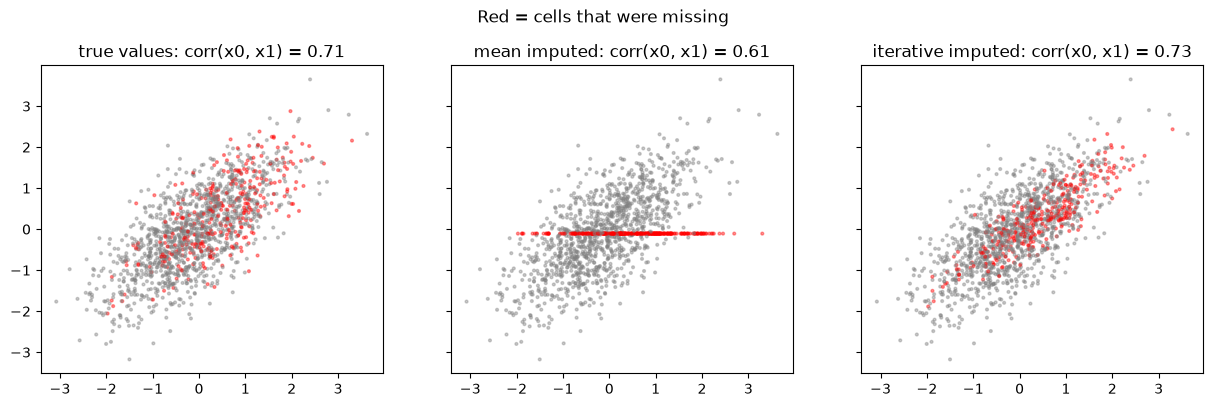

In [5]:
filled_mean = pd.DataFrame(SimpleImputer().fit_transform(df), columns=df.columns)
filled_it = pd.DataFrame(IterativeImputer(random_state=0).fit_transform(df), columns=df.columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, (name, d) in zip(axes, [("true values", df_true), ("mean imputed", filled_mean), ("iterative imputed", filled_it)]):
    ax.scatter(d.x0, d.x1, s=4, alpha=0.4, c=np.where(miss[:, 1], "r", "grey"))
    ax.set_title(f"{name}: corr(x0, x1) = {d.x0.corr(d.x1):.2f}")
plt.suptitle("Red = cells that were missing", y=1.02); plt.show()

## **3. Missing Indicators and Native NaN Support**
Sometimes "missing" is itself informative (MNAR). Add a binary **indicator** column. Gradient-boosting libraries (`HistGradientBoosting`, XGBoost, LightGBM) learn the best direction for missing values at every split, so they need no imputation.

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor

y = yfull + np.where(df.x3.isna(), 4, 0)                          # missingness itself carries signal
cands = {
    "mean impute + linear": make_pipeline(SimpleImputer(), LinearRegression()),
    "mean impute + indicator + linear": make_pipeline(SimpleImputer(add_indicator=True), LinearRegression()),
    "iterative impute + linear": make_pipeline(IterativeImputer(random_state=0), LinearRegression()),
    "iterative + indicator + linear": make_pipeline(IterativeImputer(random_state=0, add_indicator=True), LinearRegression()),
    "HistGradientBoosting (native NaN)": HistGradientBoostingRegressor(random_state=0),
}
for name, m in cands.items():
    print(f"{name:<36} CV R2 = {cross_val_score(m, df, y, cv=5, scoring='r2').mean():.3f}")

mean impute + linear                 CV R2 = 0.840
mean impute + indicator + linear     CV R2 = 0.929


iterative impute + linear            CV R2 = 0.850


iterative + indicator + linear       CV R2 = 0.945


HistGradientBoosting (native NaN)    CV R2 = 0.920


**Always impute inside a pipeline**, so the imputer learns its statistics from the training folds only.

## **4. Outlier Detection**

| Method | Rule | Notes |
|---|---|---|
| z-score | $\lvert x-\bar x\rvert/s > 3$ | Mean and std are themselves distorted by outliers |
| Robust z (MAD) | $0.6745\lvert x-\text{med}\rvert/\text{MAD} > 3.5$ | Robust |
| IQR (Tukey) | $x < Q_1-1.5\,IQR$ or $x > Q_3+1.5\,IQR$ | Robust, used in box plots |
| Isolation Forest | Points isolated by few random splits | Multivariate (Day 51) |

In [7]:
from scipy import stats
v = np.r_[rng.normal(10, 1, 200), [25, 28, 30, 2]]          # 4 gross errors
z = np.abs(stats.zscore(v))
robust_z = 0.6745 * np.abs(v - np.median(v)) / stats.median_abs_deviation(v)
q1, q3 = np.percentile(v, [25, 75]); iqr = q3 - q1
print("z-score > 3      :", np.sort(v[z > 3]).round(1))
print("robust z > 3.5   :", np.sort(v[robust_z > 3.5]).round(1))
print("IQR rule         :", np.sort(v[(v < q1 - 1.5 * iqr) | (v > q3 + 1.5 * iqr)]).round(1))

z-score > 3      : [ 2. 25. 28. 30.]
robust z > 3.5   : [ 2. 25. 28. 30.]
IQR rule         : [ 2. 25. 28. 30.]


### Multivariate outliers
A point can be normal in each feature separately but abnormal in combination.

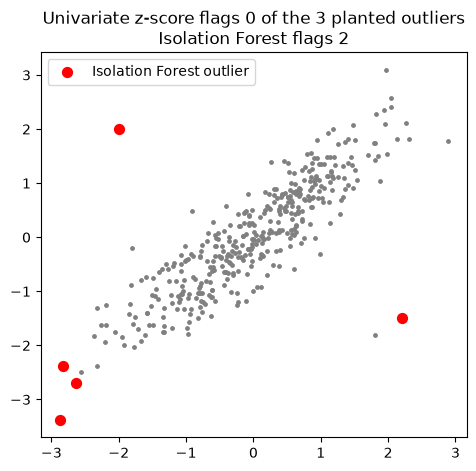

In [8]:
from sklearn.ensemble import IsolationForest
cov = [[1, 0.9], [0.9, 1]]
P = rng.multivariate_normal([0, 0], cov, 400)
P = np.r_[P, [[1.8, -1.8], [-2, 2], [2.2, -1.5]]]               # off-diagonal: each coordinate looks normal
iso = IsolationForest(contamination=0.01, random_state=0).fit(P)
flag = iso.predict(P) == -1
uni_flag = (np.abs(stats.zscore(P)) > 3).any(1)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(*P[~flag].T, s=6, c="grey"); ax.scatter(*P[flag].T, s=50, c="r", label="Isolation Forest outlier")
ax.legend(); ax.set_title(f"Univariate z-score flags {uni_flag[-3:].sum()} of the 3 planted outliers\nIsolation Forest flags {flag[-3:].sum()}")
plt.show()

## **5. What to Do With Outliers**
1. **Investigate first.** Is it an error (typo, sentinel -9999, wrong unit) or a rare real event (flood, fraud)? Real extremes are often the most important data.
2. **Errors** -> set to missing, then impute.
3. **Real but extreme** -> use robust models/losses (trees, Huber, MAE), **cap** (winsorise) at percentiles, or **transform** (log).

In [9]:
from sklearn.linear_model import HuberRegressor
xo = rng.uniform(0, 10, 100); yo = 3 * xo + rng.normal(0, 1, 100); yo[:5] += 60
capped = np.clip(yo, *np.percentile(yo, [1, 95]))
print("OLS slope            :", LinearRegression().fit(xo[:, None], yo).coef_.round(3))
print("OLS on winsorised y  :", LinearRegression().fit(xo[:, None], capped).coef_.round(3))
print("Huber slope          :", HuberRegressor().fit(xo[:, None], yo).coef_.round(3), "(true slope 3)")

OLS slope            : [2.03]
OLS on winsorised y  : [2.559]
Huber slope          : [2.998] (true slope 3)


Winsorising the target only partly helps: it also clips **genuine** high values, which bends the slope. The Huber loss (quadratic for small residuals, linear for large ones) recovers the true slope.

# **Part 2: Going Deeper - Multiple Imputation**

A single imputed value pretends to be known exactly, so downstream standard errors are too small. **Multiple imputation** (Rubin, 1987) creates $m$ completed datasets with random draws (`IterativeImputer(sample_posterior=True)`), analyses each, and pools results: total variance = within-imputation variance + $(1+1/m)\times$ between-imputation variance.

In [10]:
import statsmodels.api as sm

def pooled_mi(include_outcome, m=10):
    coefs, variances = [], []
    for i in range(m):
        data_for_imputer = np.c_[df, yfull] if include_outcome else df.values
        filled = IterativeImputer(sample_posterior=True, random_state=i).fit_transform(data_for_imputer)[:, :6]
        fit = sm.OLS(yfull, sm.add_constant(filled)).fit()
        coefs.append(fit.params[2]); variances.append(fit.bse[2] ** 2)       # coefficient of x1
    qbar, W, B = np.mean(coefs), np.mean(variances), np.var(coefs, ddof=1)
    return qbar, np.sqrt(W + (1 + 1 / m) * B)                               # Rubin's rules

single = sm.OLS(yfull, sm.add_constant(IterativeImputer(random_state=0).fit_transform(np.c_[df, yfull])[:, :6])).fit()
print(f"x1 coefficient, single imputation (with y)  : {single.params[2]:.3f} +/- {single.bse[2]:.3f}  (SE too small)")
print("x1 coefficient, multiple imputation WITHOUT y: %.3f +/- %.3f  (biased towards 0!)" % pooled_mi(False))
print("x1 coefficient, multiple imputation WITH y   : %.3f +/- %.3f  (unbiased, honest SE)" % pooled_mi(True))
print(f"x1 coefficient, complete data                : {sm.OLS(yfull, sm.add_constant(df_true.values)).fit().params[2]:.3f}   (true value 2.0)")

x1 coefficient, single imputation (with y)  : 2.203 +/- 0.038  (SE too small)


x1 coefficient, multiple imputation WITHOUT y: 1.584 +/- 0.073  (biased towards 0!)


x1 coefficient, multiple imputation WITH y   : 2.002 +/- 0.049  (unbiased, honest SE)
x1 coefficient, complete data                : 2.008   (true value 2.0)


**Rule:** the imputation model must include the **outcome**. If it does not, imputed values are drawn as if they were unrelated to $y$, and the estimated effect is pulled towards zero. (For *prediction* pipelines this does not apply: at prediction time $y$ is unknown, so imputers are fitted on features only, inside the pipeline.)

## **Practice Problems**
1. Repeat the imputer comparison with MCAR missingness. Does the ranking change?
2. Replace `-9999` values in `pd.Series([3.1, -9999, 2.8, 3.3, -9999])` by NaN and impute with the median.
3. Write a function `winsorise(s, lower=0.01, upper=0.99)` and apply it to `v`.
4. *(Advanced)* Tune `n_neighbors` of `KNNImputer` by the RMSE on artificially masked **observed** cells (mask 10% of observed values, impute, compare).

In [11]:
# Solution 1
df_mcar = df_true.mask(rng.random(df_true.shape) < 0.2)
mm = df_mcar.isna().values
for name, imp in imputers.items():
    f = imp.fit_transform(df_mcar); print(f"{name:<22} RMSE {np.sqrt(np.mean((f[mm] - df_true.values[mm]) ** 2)):.3f}")
# Solution 2
s = pd.Series([3.1, -9999, 2.8, 3.3, -9999]).replace(-9999, np.nan); print(s.fillna(s.median()).tolist())
# Solution 3
winsorise = lambda s, lower=0.01, upper=0.99: np.clip(s, *np.quantile(s, [lower, upper]))
print("max before/after:", v.max(), winsorise(v).max().round(2))
# Solution 4
obs = ~df.isna().values; hide = obs & (rng.random(df.shape) < 0.1)
df_h = df.mask(hide)
for k in [1, 3, 5, 10, 20, 50]:
    f = KNNImputer(n_neighbors=k).fit_transform(df_h)
    print(f"k={k:>2}: RMSE {np.sqrt(np.mean((f[hide] - df.values[hide]) ** 2)):.3f}")

mean                   RMSE 0.972
median                 RMSE 0.973
KNN (k=5)              RMSE 0.823
Iterative (MICE-like)  RMSE 0.681
[3.1, 3.1, 2.8, 3.3, 3.1]
max before/after: 30.0 24.62


k= 1: RMSE 1.211
k= 3: RMSE 0.947
k= 5: RMSE 0.869


k=10: RMSE 0.832
k=20: RMSE 0.804
k=50: RMSE 0.778


## **Key References**
- Rubin, D. B. (1976). Inference and missing data. *Biometrika*, 63(3), 581-592.
- van Buuren, S., & Groothuis-Oudshoorn, K. (2011). mice: Multivariate imputation by chained equations in R. *Journal of Statistical Software*, 45(3), 1-67.
- Little, R. J. A., & Rubin, D. B. (2019). *Statistical Analysis with Missing Data* (3rd ed.). Wiley.
- Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation forest. *IEEE ICDM 2008*, 413-422.
- Iglewicz, B., & Hoaglin, D. C. (1993). *How to Detect and Handle Outliers*. ASQC Quality Press.